In [2]:
import warnings
warnings.filterwarnings('ignore')

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/ed/Pandas_logo.svg/1200px-Pandas_logo.svg.png" width="25%" height="25%" />

# Pandas - Topic 09 - Data Manipulation Part 2

 <img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%202%20-%20Unit%20Objective.png">

## Topic Objectives

In this unit you will learn techniques that will assist you when you come to cleaning data sets. 

* **Replace** data in a DataFrame
* **Change** data type
* **Manage** duplicated data

---

 <img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%204%20-%20Import%20Package%20for%20Learning.png">

## Import Package for Learning

In [3]:
import numpy as np
import pandas as pd

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

# Pandas - Topic 09 - Data Manipulation Part 2

In this notebook we will cover

* how to replace data in your DataFrame using `.replace()`
* how to change the data type with `.astype()`
* how to manage duplicated data with `.duplicated()` and `.drop_duplicates()`

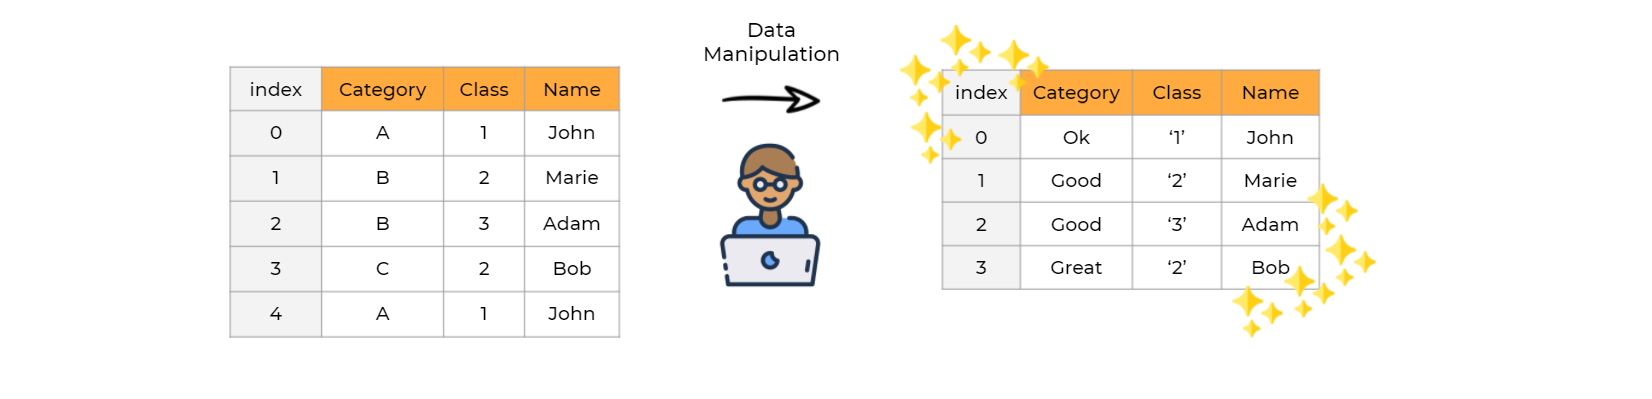

---

Consider the dataset from the previous unit

In [4]:
df = pd.DataFrame(data={'Col1':np.random.randint(low=0,high=50,size=10),
                        'Col2':np.random.randn(10),
                        'Col3':['A','B','C','A','A','C','D','B','A','A'],
                        'Col4':np.random.choice([True, False],size=10),
                        'Col5':np.random.randint(low=1,high=4,size=10),
                        'Col6':['X','X','Y','Z','Z','Z','Y','X','Z','Z']},
                  index=pd.date_range(start='01/01/2021', periods=10, freq='ME'))
df

,Col1,Col2,Col3,Col4,Col5,Col6
2021-01-31,8,0.096913,A,True,2,X
2021-02-28,39,1.502649,B,True,3,X
2021-03-31,45,0.211343,C,False,2,Y
2021-04-30,11,-0.154509,A,True,1,Z
2021-05-31,32,0.673407,A,True,3,Z
2021-06-30,15,0.662722,C,False,1,Z
2021-07-31,48,-0.271599,D,False,1,Y
2021-08-31,6,0.803606,B,True,3,X
2021-09-30,37,2.147370,A,False,3,Z
2021-10-31,46,-1.660782,A,True,1,Z


<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png">

### Replace Values

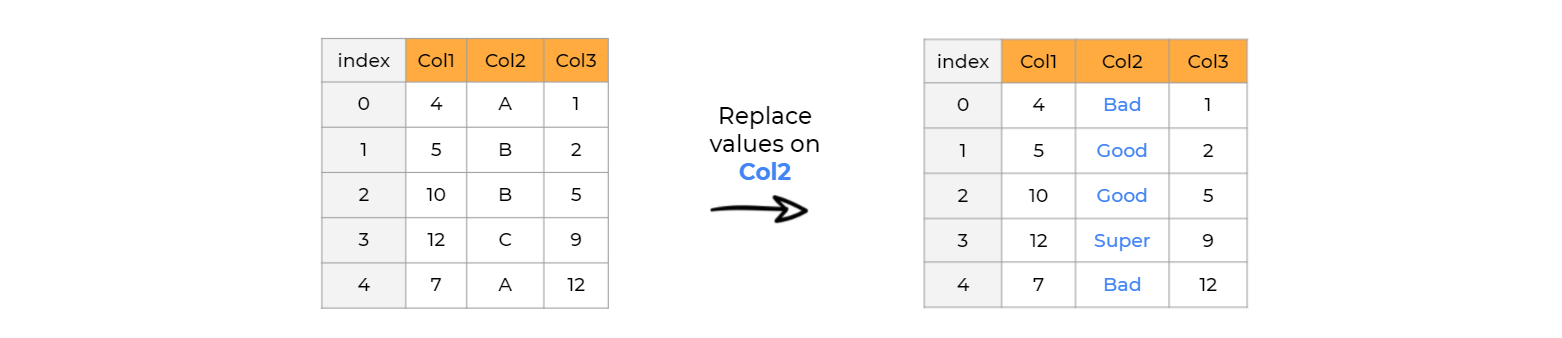

* You can replace values in your dataframe using `.replace()`. You can parse a Python dictionary that will map the values in the '`to_replace`' argument
  * For teaching purposes, first, we create a Python dictionary that maps the character keys to human-readable category values. We will map Col3 values to numbers
  *The function documentation can be found [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.replace.html)

In [5]:
map_dict = {'A': 'Nice', 'B': 'Super', 'C':'Amazing', 'D':'Incredible'}
map_dict

{'A': 'Nice', 'B': 'Super', 'C': 'Amazing', 'D': 'Incredible'}

We now parse this dictionary
* You can do that in one line. We broke it into two lines for a better learning experience

* Remember that in the example below, we overwrote the existing DataFrame since we set `inplace=True`

In [6]:
df['Col3'].replace(to_replace=map_dict, inplace=True)
df

,Col1,Col2,Col3,Col4,Col5,Col6
2021-01-31,8,0.096913,Nice,True,2,X
2021-02-28,39,1.502649,Super,True,3,X
2021-03-31,45,0.211343,Amazing,False,2,Y
2021-04-30,11,-0.154509,Nice,True,1,Z
2021-05-31,32,0.673407,Nice,True,3,Z
2021-06-30,15,0.662722,Amazing,False,1,Z
2021-07-31,48,-0.271599,Incredible,False,1,Y
2021-08-31,6,0.803606,Super,True,3,X
2021-09-30,37,2.147370,Nice,False,3,Z
2021-10-31,46,-1.660782,Nice,True,1,Z


---

You can replace numbers with a category. The example below replaces the categories from Col6 to numbers

In [7]:
df['Col6'].replace(to_replace={'X': 1, 'Y': 20, 'Z':4000}, inplace=True)
df

,Col1,Col2,Col3,Col4,Col5,Col6
2021-01-31,8,0.096913,Nice,True,2,1
2021-02-28,39,1.502649,Super,True,3,1
2021-03-31,45,0.211343,Amazing,False,2,20
2021-04-30,11,-0.154509,Nice,True,1,4000
2021-05-31,32,0.673407,Nice,True,3,4000
2021-06-30,15,0.662722,Amazing,False,1,4000
2021-07-31,48,-0.271599,Incredible,False,1,20
2021-08-31,6,0.803606,Super,True,3,1
2021-09-30,37,2.147370,Nice,False,3,4000
2021-10-31,46,-1.660782,Nice,True,1,4000


You can check the columns' data types and note: Col6 is not categorical (object) anymore.


In [8]:
df.dtypes

Col1      int64
Col2    float64
Col3     object
Col4       bool
Col5      int64
Col6      int64
dtype: object

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png">

 **PRACTICE**: Consider this dataset which consists of 10,000 customers age, salary, marital_status, credit card limit, credit card category, etc. Such datasets are used to predict which clients will stop using the service (churn) so management can proactively go to the customer to provide them better services and reverse customers' decisions.

In [9]:
df_practice = pd.read_csv("BankChurners.csv")
df_practice.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


The variable to predict is Attrition_Flag with 2 possible values

In [10]:
df_practice['Attrition_Flag'].unique()

array(['Existing Customer', 'Attrited Customer'], dtype=object)

As you want to recognize the client which is going to attrit from our service, replace “Attrited Customer” with 1 and "Existing Customer" with 0. Your output should look like:

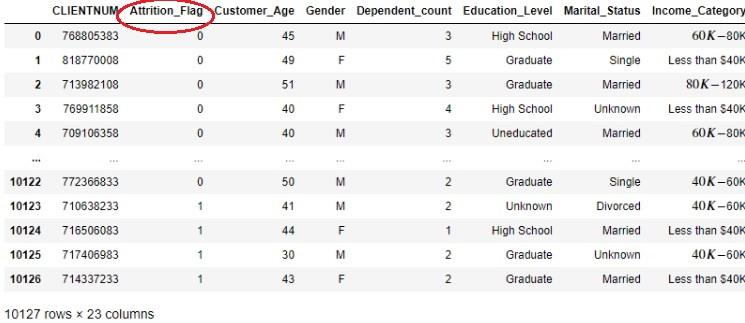

In [11]:
# write your code here.
# You should use inplace=True
df_practice['Attrition_Flag'].replace(to_replace={'Existing Customer': 0, 'Attrited Customer': 1}, inplace=True)
df_practice

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,0,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,0,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,0,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,0,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,0,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,0,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,2,3,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462
10123,710638233,1,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,2,3,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511
10124,716506083,1,44,F,1,High School,Married,Less than $40K,Blue,36,...,3,4,5409.0,0,5409.0,0.819,10291,60,0.818,0.000
10125,717406983,1,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,3,3,5281.0,0,5281.0,0.535,8395,62,0.722,0.000


---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

### Change data type

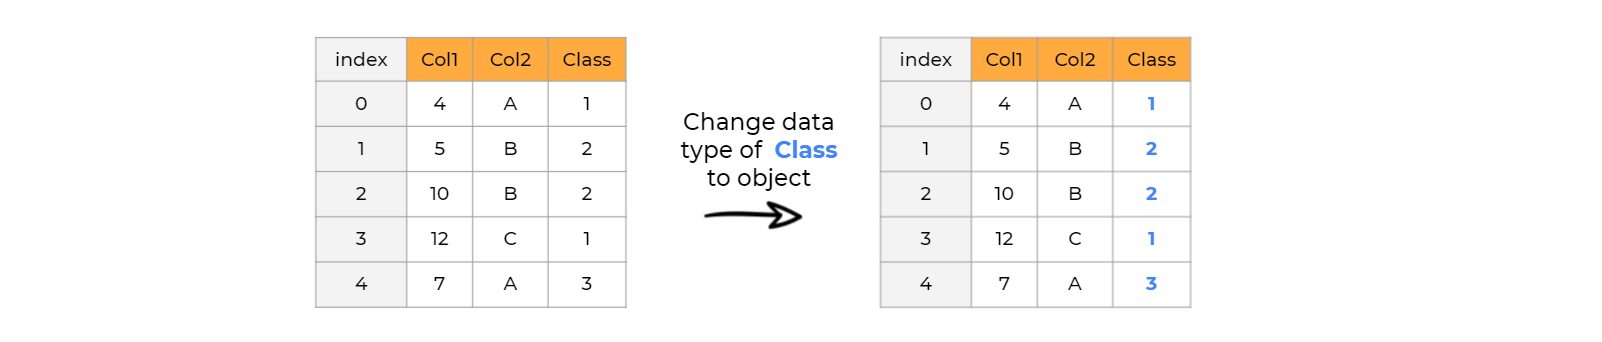

In [12]:
df.head(3)

,Col1,Col2,Col3,Col4,Col5,Col6
2021-01-31,8,0.096913,Nice,True,2,1
2021-02-28,39,1.502649,Super,True,3,1
2021-03-31,45,0.211343,Amazing,False,2,20


You notice that the data type of `Col5` is integer. However, you were informed that the content should be categorical. Imagine if the meaning of this variable is 'quality' and ranges from 1 to 3, where 1 is low quality and 3 is good quality.
  * Now you want to convert `Col5` to categorical/object, so you can properly conduct your data analysis
  * `.astype()` doesn't have an '`inplace`' argument, so you can re-assign the DataFrame content like:

In [13]:
df = df.astype({"Col5":"object"})
df

,Col1,Col2,Col3,Col4,Col5,Col6
2021-01-31,8,0.096913,Nice,True,2,1
2021-02-28,39,1.502649,Super,True,3,1
2021-03-31,45,0.211343,Amazing,False,2,20
2021-04-30,11,-0.154509,Nice,True,1,4000
2021-05-31,32,0.673407,Nice,True,3,4000
2021-06-30,15,0.662722,Amazing,False,1,4000
2021-07-31,48,-0.271599,Incredible,False,1,20
2021-08-31,6,0.803606,Super,True,3,1
2021-09-30,37,2.147370,Nice,False,3,4000
2021-10-31,46,-1.660782,Nice,True,1,4000


* When you check the data type of Col5, you will see that it is an object

In [14]:
df.dtypes

Col1      int64
Col2    float64
Col3     object
Col4       bool
Col5     object
Col6      int64
dtype: object

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png">

 **PRACTICE**: Consider the `df_practice` below. 

Note that `CLIENTNUM`	and `Attrition_Flag` are integers, but we would like them to be `categorical` and `boolean`, respectively.

In [15]:
df_practice[['CLIENTNUM', 'Attrition_Flag']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   CLIENTNUM       10127 non-null  int64
 1   Attrition_Flag  10127 non-null  int64
dtypes: int64(2)
memory usage: 158.4 KB


Change the data type of `CLIENTNUM` and `Attrition_Flag` to categorical and boolean, respectively. Then run `df_practice[['CLIENTNUM', 'Attrition_Flag']].info()` to validate their type 

Your output should look like

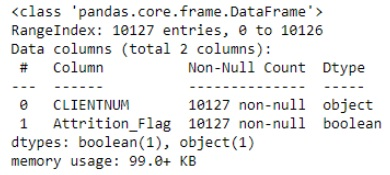

In [16]:
# write your code here
df_practice = df_practice.astype({"CLIENTNUM":"object", "Attrition_Flag":"boolean"})
df_practice[['CLIENTNUM', 'Attrition_Flag']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CLIENTNUM       10127 non-null  object 
 1   Attrition_Flag  10127 non-null  boolean
dtypes: boolean(1), object(1)
memory usage: 99.0+ KB


---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

### Managing duplicated data

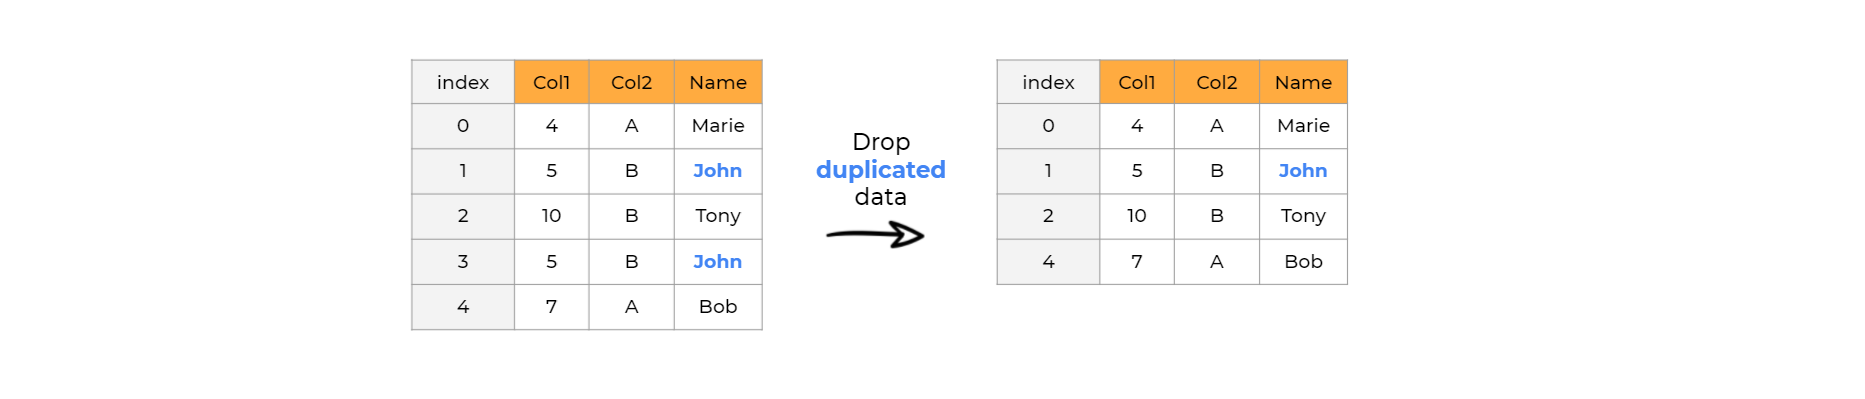

* You can check and drop duplicated data. Consider the DataFrame below

In [17]:
df = pd.DataFrame(data={'Name':['John','Marie','Joseph','John','Willian','Marie'],
                        'CustomerRate':[1,2,2,4,3,3]}
                  )
df

,Name,CustomerRate
0,John,1
1,Marie,2
2,Joseph,2
3,John,4
4,Willian,3
5,Marie,3


It is decided for this DataFrame that each `Name` should be unique. For some reason, John and Marie are repeated, even though the `CustomerRate` is different. 

However, in this case, it should have only 1 John and only 1 Marie.
* Use `.duplicated()` to grab rows which are repeated in the column you are interested in. 
* Use the ``subset`` argument to only consider certain columns for identifying duplicates. By default, it uses all columns to check for duplication, but  in this case, we are interested only in '`Name`'.  The documentation is [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.duplicated.html)

In [18]:
df.duplicated(subset=['Name'])

0    False
1    False
2    False
3     True
4    False
5     True
dtype: bool

The result is a boolean series, so we parse that to the DataFrame to get the rows themselves. 


  * We can see that indexes 3 and 5 are duplicated, which happens to be John and Marie
  * By default, when finding a duplicate, it doesn't mark as duplicate the first occurrence. In the example, it says index 0 (John) is not duplicated, but index 3 is a duplicate

In [19]:
df[df.duplicated(subset=['Name'])]

,Name,CustomerRate
3,John,4
5,Marie,3


* But maybe you are interested to see all data marked as duplicated, so you can decide which to remove.
  * In the example, the row with the index of 0 is the duplicate of 3, not the opposite. In this case, set the '`keep`' argument as `False` to see all that are duplicates

In [20]:
df[df.duplicated(subset=['Name'], keep=False)]

,Name,CustomerRate
0,John,1
1,Marie,2
3,John,4
5,Marie,3


* You can drop duplicate rows with the method `.drop_duplicates()`; the documentation is [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop_duplicates.html)
* Note we set `subset='Name'` to find duplicates in the column: **Name** 
* And we set `inplace=True`, so we overwrite the DataFrame

In [21]:
df.drop_duplicates(subset=['Name'], inplace=True)
df

,Name,CustomerRate
0,John,1
1,Marie,2
2,Joseph,2
4,Willian,3


---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png"> 

**PRACTICE**: Consider the dataset which contains information on transactions made by customers through an online retail platform. The dataset includes data on the products that were purchased, the quantity of each product, the date and time of each transaction, the price of each product, the unique identifier for each customer who made a purchase, and the country where each customer is located.
* We have the information that the pair `InvoiceNo`, `StockCode` and `CustomerID` should be unique. For some fictitious reason, a given customer can buy only a given product once per invoice.

In [28]:
df_practice = pd.read_csv("Online_Retail.csv")
df_practice

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,547561,23127,DOLLCRAFT GIRL NICOLE,4,3/24/11 8:44,4.95,14129.0,United Kingdom
1,547561,23128,DOLLCRAFT BOY JEAN-PAUL,4,3/24/11 8:44,4.95,14129.0,United Kingdom
2,547561,23126,DOLLCRAFT GIRL AMELIE,4,3/24/11 8:44,4.95,14129.0,United Kingdom
3,547561,23077,DOUGHNUT LIP GLOSS,20,3/24/11 8:44,1.25,14129.0,United Kingdom
4,547561,84375,SET OF 20 KIDS COOKIE CUTTERS,12,3/24/11 8:44,2.10,14129.0,United Kingdom
...,...,...,...,...,...,...,...,...
10678,548548,22423,REGENCY CAKESTAND 3 TIER,1,3/31/11 19:54,12.75,17781.0,United Kingdom
10679,548548,21361,LOVE LARGE WOOD LETTERS,7,3/31/11 19:54,12.75,17781.0,United Kingdom
10680,548549,84763,ZINC FINISH 15CM PLANTER POTS,100,3/31/11 19:55,1.06,16365.0,United Kingdom
10681,548549,22222,CAKE PLATE LOVEBIRD WHITE,1,3/31/11 19:55,4.95,16365.0,United Kingdom


You should show all data marked as duplicated.


Your output should look like

![duplicate](https://codeinstitute.s3.eu-west-1.amazonaws.com/predictive_analytics/jupyter_notebook_images/Screenshot+2024-05-22+170727.png)

In [31]:
# write your code here
df_practice[df_practice.duplicated(subset=['InvoiceNo', 'StockCode', 'CustomerID'])]


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
493,547650,22084,PAPER CHAIN KIT EMPIRE,4,3/24/11 12:08,2.95,17059.0,United Kingdom
497,547650,22989,SET 2 PANTRY DESIGN TEA TOWELS,4,3/24/11 12:08,3.25,17059.0,United Kingdom
517,547651,82613A,"METAL SIGN,CUPCAKE SINGLE HOOK",1,3/24/11 12:11,1.25,16904.0,United Kingdom
518,547651,82613C,"METAL SIGN,CUPCAKE SINGLE HOOK",1,3/24/11 12:11,1.25,16904.0,United Kingdom
519,547651,82613D,METAL SIGN CUPCAKE SINGLE HOOK,1,3/24/11 12:11,1.25,16904.0,United Kingdom
...,...,...,...,...,...,...,...,...
10021,548512,21922,UNION STRIPE WITH FRINGE HAMMOCK,1,3/31/11 15:54,7.95,14410.0,United Kingdom
10293,548516,85123A,WHITE HANGING HEART T-LIGHT HOLDER,3,3/31/11 16:28,2.95,NaN,United Kingdom
10294,548516,22423,REGENCY CAKESTAND 3 TIER,5,3/31/11 16:28,9.86,NaN,United Kingdom
10638,548544,22294,HEART FILIGREE DOVE SMALL,24,3/31/11 18:49,1.25,14525.0,United Kingdom


Then, drop the duplicates. Your output should look as shown below. Pay attention to the indices you saw in the previous practice to check which rows were removed.

![drop](https://codeinstitute.s3.eu-west-1.amazonaws.com/predictive_analytics/jupyter_notebook_images/Screenshot+2024-05-22+170748.png)

In [24]:
# write your code here
df_practice.drop_duplicates(subset=['InvoiceNo', 'StockCode', 'CustomerID'], inplace=True)
df_practice

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,547561,23127,DOLLCRAFT GIRL NICOLE,4,3/24/11 8:44,4.95,14129.0,United Kingdom
1,547561,23128,DOLLCRAFT BOY JEAN-PAUL,4,3/24/11 8:44,4.95,14129.0,United Kingdom
2,547561,23126,DOLLCRAFT GIRL AMELIE,4,3/24/11 8:44,4.95,14129.0,United Kingdom
3,547561,23077,DOUGHNUT LIP GLOSS,20,3/24/11 8:44,1.25,14129.0,United Kingdom
4,547561,84375,SET OF 20 KIDS COOKIE CUTTERS,12,3/24/11 8:44,2.10,14129.0,United Kingdom
...,...,...,...,...,...,...,...,...
10678,548548,22423,REGENCY CAKESTAND 3 TIER,1,3/31/11 19:54,12.75,17781.0,United Kingdom
10679,548548,21361,LOVE LARGE WOOD LETTERS,7,3/31/11 19:54,12.75,17781.0,United Kingdom
10680,548549,84763,ZINC FINISH 15CM PLANTER POTS,100,3/31/11 19:55,1.06,16365.0,United Kingdom
10681,548549,22222,CAKE PLATE LOVEBIRD WHITE,1,3/31/11 19:55,4.95,16365.0,United Kingdom
